---
title: "Cloudy with a chance of animations"
subtitle: "using PyVista in cloud physics simulations."
author: "Alicja Jagielska, Aleksandra Strząbała"
date:  2026-05-23
title-slide-attributes:
  data-background-image: backgorunds/title.png
  data-background-size: contain
  data-background-opacity: "0.5"
format:
  revealjs:
    width: 1920
    height: 1080
    header-includes: |
        <style>
            .reveal .slides section {
                display: flex !important;
                flex-direction: column !important;
                align-items: center !important;
                justify-content: center !important;
                padding-bottom: 200px !important;
            }
        </style>
    title-slide-attributes:
        data-background-image: "backgrounds/title.png"
        data-background-size: cover
        data-background-opacity: "1"
    background-image: backgrounds/slide.png
    margin-bottom: 0.05
    slide-number: true
    transition: zoom
    background-transition: fade
    theme: sky
    citation-style: https://raw.githubusercontent.com/citation-style-language/styles/master/chicago-notes-classic.csl
bibliography: refs.bib
---

In [ ]:
!pip install PySDM-examples==3.0.0rc31 PySDM==3.0.0rc31 PyMPDATA-examples qrcode pyvista[jupyter]

In [2]:
with open("refs.bib", "w", encoding="utf8") as f:
    f.write(r"""
@article{Arabas2017,
  year = {2017},
  title = {On the CCN (de)activation nonlinearities},
  author = {Arabas, S., Shima, S.},
  publisher = {Nonlin. Processes Geophys.}
}
@misc{pego2020,
    year = {2020},
    author = {Rober Pego},
    note = {Last accessed 22 May 2026},
    url = {https://www.youtube.com/watch?v=3712lImYP84}
}
@book{BohrenBeer,
    year = {2001},
    title = {Clouds in a glass of beer: simple experiments in atmospheric physics},
    author = {Craig F. Bohren},
    publisher = {Dover Publications}
}
@misc{strzabala,
    year = {2020},
    author = {Rober Pelgo},
    note = {Last accessed 22 May 2026},
    url = {https://www.youtube.com/watch?v=3712lImYP84}
}
@misc{kowalczyk,
    year = {2020},
    author = {Rober Pelgo},
    note = {Last accessed 22 May 2026},
    url = {https://www.youtube.com/watch?v=3712lImYP84}
}
@article{sullivan2019pyvista,
  doi = {10.21105/joss.01450},
  url = {https://doi.org/10.21105/joss.01450},
  year = {2019},
  month = {May},
  publisher = {The Open Journal},
  volume = {4},
  number = {37},
  pages = {1450},
  author = {Bane Sullivan and Alexander Kaszynski},
  title = {{PyVista}: {3D} plotting and mesh analysis through a streamlined interface for the {Visualization Toolkit} ({VTK})},
  journal = {Journal of Open Source Software}
}
@article{de-Jong2023,
    doi = {10.21105/joss.04968},
    url = {https://doi.org/10.21105/joss.04968},
    year = {2023},
    publisher = {The Open Journal},
    volume = {8},
    number = {84},
    pages = {4968},
    author = {de Jong, Emily K. and Singer, Clare E. and Azimi, Sajjad and Bartman, Piotr and Bulenok, Oleksii and Derlatka, Kacper and Dula, Isabella and Jaruga, Anna and Mackay, J. Ben and Ward, Ryan X. and Arabas, Sylwester},
    title = {New developments in PySDM and PySDM-examples v2: collisional breakup, immersion freezing, dry aerosol initialization, and adaptive time-stepping},
    journal = {Journal of Open Source Software}
}
@Article{Hunter2007,
  Author    = {Hunter, J. D.},
  Title     = {Matplotlib: A 2D graphics environment},
  Journal   = {Computing in Science \& Engineering},
  Volume    = {9},
  Number    = {3},
  Pages     = {90--95},
  abstract  = {Matplotlib is a 2D graphics package used for Python for
  application development, interactive scripting, and publication-quality
  image generation across user interfaces and operating systems.},
  publisher = {IEEE COMPUTER SOC},
  doi       = {10.1109/MCSE.2007.55},
  year      = 2007
}
@article{Bartman2022,
    doi = {10.21105/joss.03896},
    url = {https://doi.org/10.21105/joss.03896},
    year = {2022}, publisher = {The Open Journal},
    volume = {7},
    number = {77},
    pages = {3896},
    author = {Bartman, Piotr and Banaśkiewicz, Jakub and Drenda, Szymon and Manna, Maciej and Olesik, Michael A. and Rozwoda, Paweł and Sadowski, Michał and Arabas, Sylwester},
    title = {PyMPDATA v1: Numba-accelerated implementation of MPDATA with examples in Python, Julia and Matlab},
    journal = {Journal of Open Source Software} }
""")

In [3]:
import os
import warnings
from collections import namedtuple

from numba import njit as jit
from numba.core.errors import NumbaExperimentalFeatureWarning

import pyvista as pv
from pyvista import examples

from matplotlib import colors, pyplot
import ipywidgets
from IPython.display import display

from open_atmos_jupyter_utils import show_plot
from open_atmos_jupyter_utils.show_anim import show_anim

import qrcode
from qrcode.constants import ERROR_CORRECT_L
from qrcode.image.svg import SvgPathImage

import numpy as np
from PySDM import Formulae
from PySDM.physics import si, in_unit
from PySDM.initialisation.spectra import Lognormal
from PySDM.products import (
    ParcelDisplacement,
    AmbientDryAirDensity,
    AmbientRelativeHumidity,
)
from PySDM.exporters import VTKExporterParcel
from PySDM_examples.Pyrcel import Settings, Simulation
from PyMPDATA import Options, ScalarField, VectorField, Solver, Stepper
from PyMPDATA.boundary_conditions import Periodic
from PyMPDATA.impl.enumerations import IMPL_META_AND_DATA, META_AND_DATA_DATA, IMPL_BC
from PyMPDATA.impl.clock import clock

## Presentation plan

1. What exactly is cloud physics?
2. Open-Atmos-KRK - who are we?
3. Example simulations - comparing PyVista to Matplotlib and Paraview
    - using PySDM
    - using PyMPDATA
4. Plans for the future

# What is cloud physics?

## {auto-animate=true auto-animate-easing="ease-in-out"}

::: {.r-hstack}
::: {data-id="box1" auto-animate-delay="0" style="background: #067cbd; width: 400px; height: 400px; margin: 10px; display: flex; align-items: center; justify-content: center; text-align: center; color: white; font-weight: bold; margin: 10px;"}
Environmental Physics
:::
::: {data-id="box2" auto-animate-delay="0.1" style="background: #0a9fdd; width: 400px; height: 400px; margin: 10px; display: flex; align-items: center; justify-content: center; text-align: center; color: white; font-weight: bold; margin: 10px;"}
Atmospheric Physics
:::
::: {data-id="box3" auto-animate-delay="0.2" style="background: #8eaccd; width: 400px; height: 400px; margin: 10px; display: flex; align-items: center; justify-content: center; text-align: center; color: white; font-weight: bold; margin: 10px;"}
Cloud Physics
:::
:::

## {auto-animate=true auto-animate-easing="ease-in-out"}

::: {.r-stack}
::: {data-id="box1" style="background: #067cbd; width: 1000px; height: 450px; text-align: left; color: white; font-weight: bold;  border-radius: 400px;"}
Environmental Physics
:::

::: {data-id="box2" style="background: #0a9fdd; width: 450px; height: 350px; display: flex; align-items: right; justify-content: left; text-align: center; color: white; font-weight: bold; border-radius: 200px;"}
Atmospheric Physics
:::

::: {data-id="box3" style="background: #8eaccd; width: 250px; height: 150px; text-align: center; color: white; font-weight: bold; border-radius: 200px;"}
Cloud Physics
:::
:::

## Cloud physics

- Weather forecast
- Power engineering
- Aviation
- ...

## But also...

::: {.fragment .fade-up}
The same equations can demonstrate different things
:::

::: {.v-stack}
::: {data-id="box1" style="background: #8eaccd; width: 1100px; height: 100px; margin: 10px; display: flex; align-items: center; justify-content: center; text-align: center; color: white; font-weight: bold; border-radius: 300px;"}
::: {.fragment .fade-up}
coagulation dynamics -> formation of the planets [@Pego2020]
:::
:::

::: {data-id="box1" style="background: #8eaccd; width: 1100px; height: 100px; margin: 10px; display: flex; align-items: center; justify-content: center; text-align: center; color: white; font-weight: bold; border-radius: 300px;"}
::: {.fragment .fade-up}
clouds flow -> flows in the sea -> blood flow (blood cells)
:::
:::

::: {data-id="box1" style="background: #8eaccd; width: 1100px; height: 100px; margin: 10px; display: flex; align-items: center; justify-content: center; text-align: center; color: white; font-weight: bold; border-radius: 300px;"}
::: {.fragment .fade-up}
clouds in beer bottles ^[B footnote]
:::
:::
:::

#  Open-Atmos-KRK - who are we?

## Our team {background-iframe="https://open-atmos-krk.github.io", background-interactive=True}

In [4]:
LINK1 = "https://open-atmos-krk.github.io/"

qr = qrcode.QRCode(
    version=None,
    error_correction=ERROR_CORRECT_L,
    box_size=10,
    border=0
)
qr.add_data(LINK1)
qr.make(fit=True)

qr_img = qr.make_image(
    image_factory=SvgPathImage,
    fill_color="black",
    back_color="white",
)

qr_img.save('team-code.svg')

![](team-code.svg){.absolute top=200 right=0 width="400" height="400"}

## Our projects {background-iframe="https://open-atmos-krk.github.io/projects.html", background-interactive=True}

# Example simulations - comparing PyVista to Matplotlib and Paraview

## PyVista[sullivan2019pyvista] introduction

In [5]:
#| echo: true
dataset = examples.download_dragon()

pl = pv.Plotter()
pl.add_mesh(dataset)
pl.export_html("test.html")

<iframe src="test.html" width="100%" heighth="1000px" frameborder="0"></iframe>

## Parcel animation using PySDM[de-Jong2023]

In [6]:
settings = Settings(
    dz=10 * si.m,
    n_sd_per_mode=(50, 50),
    aerosol_modes_by_kappa={
        0.54: Lognormal(
            norm_factor=850 / si.cm**3,
            m_mode=15 * si.nm,
            s_geom=1.6,
        ),
        1.2: Lognormal(
            norm_factor=10 / si.cm**3,
            m_mode=850 * si.nm,
            s_geom=1.2,
        ),
    },
    vertical_velocity=3.0 * si.m / si.s,
    initial_pressure=775 * si.mbar,
    initial_temperature=274 * si.K,
    initial_relative_humidity=0.967,
    displacement=490 * si.m,
    formulae=Formulae(constants={"MAC": 0.3}),
)

dry_radius_bin_edges = np.logspace(
    np.log10(1e-3 * si.um), np.log10(5e0 * si.um), 33, endpoint=False
)

simulation = Simulation(
    settings,
    products=(
        ParcelDisplacement(name="z"),
        AmbientRelativeHumidity(name="S_max_percent", unit="%", var="RH"),
        AmbientDryAirDensity(),
    ),
    mass_of_dry_air = 66666 * si.kg,
    additional_attributes = ("radius",)
)

In [7]:
output = simulation.run()

In [8]:
e = VTKExporterParcel(n_sd=simulation.particulator.n_sd, output=output, mass_of_dry_air=simulation.particulator.environment.mass_of_dry_air)
for step in settings.output_steps:
    e.export_products(step, simulation)
    e.export_attributes(step, simulation)
e.write_pvd()

In [9]:
pv.set_jupyter_backend('static')
readers = {
    'prod': pv.get_reader("./output/sd_products.pvd"),
    'attr': pv.get_reader("./output/sd_attributes.pvd")
}


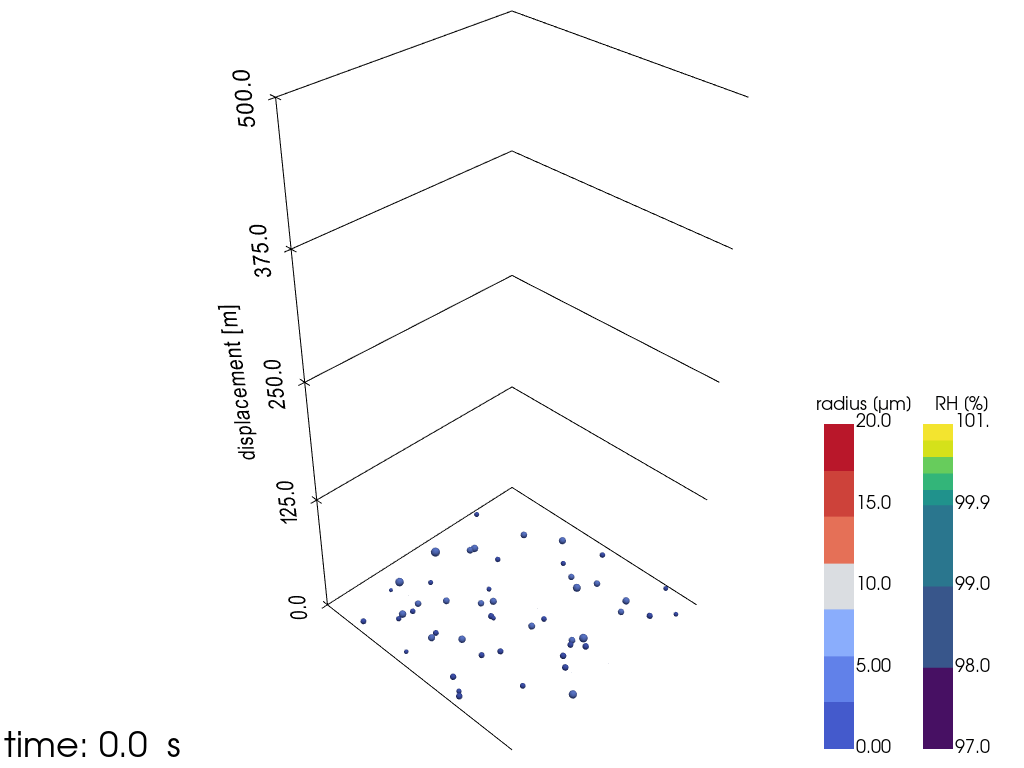

HTML(value="<a href='./parcel_animation.gif' target='_blank'>./parcel_animation.gif</a><br>")

In [10]:
#| echo: true
#| output-location: slide

from open_atmos_jupyter_utils import TemporaryFile
gif_file = TemporaryFile(filename="output/parcel_animation.gif")

readers['prod'].set_active_time_point(readers['prod'].number_time_points -1)
data = readers['prod'].read()[0]
prod_min, prod_max = data.get_data_range('RH')


mesh_actor = None
attr_actor = None
title_actor = None
cube_axes_actor = None

def attr_log10_range(attr):
    log_value_min, log_value_max = float('inf'), float('-inf')
    for j in range(readers['attr'].number_time_points):
        readers['attr'].set_active_time_point(j)
        value = readers['attr'].read()[0].point_data[attr]
        log_value = np.log10(value)
        log_value_min = min(log_value_min, log_value.min())
        log_value_max = max(log_value_max, log_value.max())
    return log_value_min, log_value_max

log_vol_min, log_vol_max = attr_log10_range("volume")

pl = pv.Plotter(notebook=False, off_screen=True)
pl.open_gif(gif_file.basename, subrectangles=True)

axes_ranges = readers['prod'].read()[0].GetBounds()

for i in range(readers['prod'].number_time_points):
    for reader in readers.values():
        reader.set_active_time_point(i)

    if mesh_actor is not None:
        pl.remove_actor(mesh_actor)

    if attr_actor is not None:
        pl.remove_actor(attr_actor)

    if title_actor is not None:
        pl.remove_actor(title_actor)

    if cube_axes_actor is not None:
        pl.remove_actor(cube_axes_actor)

    title_actor = pl.add_text(
        f"time: {readers['prod'].active_time_value:.1f}  s ",
        position='lower_left',
        font_size=14,
        color='black'
    )

    attr_data = readers['attr'].read()[0]
    radius = attr_data.point_data['radius'].copy()

    attr_data.point_data['vol_display'] = in_unit(radius, si.um)

    glyphed = attr_data.glyph(
        scale='vol_display',
        geom=pv.Sphere(radius=1.0),
        orient=False,
    )

    glyphed = attr_data.glyph(
        scale='vol_display',
        geom=pv.Sphere(radius=1.0),
        orient=False,
    )

    mesh_actor = pl.add_mesh(
        readers['prod'].read()[0],
        scalars='RH',
        cmap = colors.ListedColormap(['#471063']*5 + ['#38568B']*5 + ['#2A768E']*5 + ['#20928C', '#33B579', '#67CC5C', '#D5E11A', '#F3E42F']),
        clim=[prod_min, prod_max],
        scalar_bar_args={"title": "RH [%]", "vertical": True},
        opacity = 0.666,
        remove_existing_actor = True,
        nan_color = "white",
        nan_opacity = 0.0
    )

    attr_actor = pl.add_mesh(
        glyphed,
        scalars='vol_display',
        cmap = colors.ListedColormap(['#445ACC', '#6181E9','#8AADFC', '#DADDE1', '#E57057', '#CD423A', '#B9172A']),
        clim=[0, 20],
        scalar_bar_args={"title": "radius [μm]", "vertical": True},
    )
    pl.show_grid(bounds=axes_ranges, show_xlabels=False, show_ylabels=False, xtitle=" ", ytitle=" ", ztitle="displacement [m]")

    pl.render()
    pl.write_frame()
pl.close()

from open_atmos_jupyter_utils import show_gif
show_gif(gif_file)

## 2D Boussinesq (buoyancy-driven) flow example using PyMPDATA

In [11]:
OPTIONS = Options(n_iters=2, infinite_gauge=True, nonoscillatory=True)
CI = 'CI' in os.environ
CI=True

SETUP = {
    "outfreq": 1,
    "N": 200 if not CI else 100,
    "M": 200 if not CI else 100,
    "Tht_ref": 300.,
    "Tht_dlt": .5,
    "g": 9.81,
    "r0": 250.,
    "x0": 1000,
    "y0": 260,
    "dt": 0.75 if not CI else 1.5,
    "prs_tol": 1e-7,
    "k_iters": 4,
}

SETUP["nt"] = int(600//SETUP["dt"])
SETUP["err_tol"] = SETUP["prs_tol"] / SETUP["dt"]
SETUP["grid"] = SETUP["N"], SETUP["M"]
SETUP["dxy"] = (2000/SETUP["N"], 2000/SETUP["M"])
SETUP["halo"] = OPTIONS.n_halo
SETUP["grid_with_halo"] = SETUP["N"] + SETUP["halo"]*2, SETUP["M"] + SETUP["halo"]*2

SETUP = namedtuple("Setup", SETUP.keys())(**SETUP)

assert SETUP.dt * SETUP.nt == 600

In [12]:
xi, yi = np.indices(SETUP.grid)

mesh = np.full(SETUP.grid, fill_value=SETUP.Tht_ref, dtype=float)
mesh += np.where(
    np.sqrt(
        ((xi+1/2) * SETUP.dxy[0] - SETUP.x0)**2 +
        ((yi+1/2) * SETUP.dxy[1] - SETUP.y0)**2
    ) < SETUP.r0,
    SETUP.Tht_dlt,
    0
)

In [13]:
_U, _W, _T = 0, 1, 2

bcond = (Periodic(), Periodic())
field_ctor_kwargs = {'halo': SETUP.halo, 'boundary_conditions': bcond}


stepper = Stepper(options=OPTIONS, grid=SETUP.grid,n_threads = 1)


def new_sf(g):
    field = ScalarField(data=np.zeros(g), **field_ctor_kwargs)
    field.assemble(stepper.traversals)
    return field



def initialize():
    advector = VectorField(data=(
            np.zeros((SETUP.N+1, SETUP.M)),
            np.zeros((SETUP.N, SETUP.M+1))
        ), **field_ctor_kwargs)
    advector.assemble(stepper.traversals)
    solver_ctor_kwargs = {'stepper': stepper, 'advector': advector}
    solvers = {
        _U: Solver(advectee=new_sf(SETUP.grid), **solver_ctor_kwargs),
        _W: Solver(advectee=new_sf(SETUP.grid), **solver_ctor_kwargs),
        _T: Solver(advectee=ScalarField(data=mesh, **field_ctor_kwargs), **solver_ctor_kwargs),
    }



    ADVECTEE_DATA = tuple(
        solvers[idx].advectee.data for idx in range(3)
    )

    ADVECTOR_DATA = tuple(
        datum for datum in advector.data
    )

    ARRAYS = {
        "rhs_w": np.zeros(SETUP.grid),
        "stash": np.zeros((len(SETUP.grid), *SETUP.grid_with_halo)),
        "vip_rhs": np.zeros((len(SETUP.grid), *SETUP.grid_with_halo)),
        "Phi": np.zeros(SETUP.grid_with_halo),
        "tmp_uvw": np.zeros((len(SETUP.grid), *SETUP.grid_with_halo)),
        "lap_tmp": np.zeros((len(SETUP.grid), *SETUP.grid_with_halo)),
        "lap_err": np.zeros(SETUP.grid),
        "err": np.zeros(SETUP.grid_with_halo),
        "p_err": np.zeros((SETUP.k_iters, *SETUP.grid_with_halo)),
        "lap_p_err": np.zeros((SETUP.k_iters, *SETUP.grid)),
    }
    ARRAYS = namedtuple("Arrays", ARRAYS.keys())(**ARRAYS)
    return ARRAYS, ADVECTOR_DATA, ADVECTEE_DATA, solvers

IDX = {
    "interior": (slice(SETUP.halo, -SETUP.halo), slice(SETUP.halo, -SETUP.halo)),
    "grad_left": (
        (slice(SETUP.halo + 1, None if SETUP.halo==1 else (-SETUP.halo+1)), slice(SETUP.halo,-SETUP.halo)),
        (slice(SETUP.halo,-SETUP.halo), slice(SETUP.halo+1,None if SETUP.halo==1 else (-SETUP.halo+1)))
    ),
    "grad_right": (
        (slice(None if SETUP.halo==1 else (SETUP.halo-1),-SETUP.halo-1), slice(SETUP.halo,-SETUP.halo)),
        (slice(SETUP.halo,-SETUP.halo), slice(None if SETUP.halo==1 else (SETUP.halo-1), -SETUP.halo-1))
    ),
    "intrp_left": (
        (slice(None, -1), slice(None, None)),
        (slice(None, None), slice(None, -1)),
    ),
    "intrp_right": (
        (slice(1, None), slice(None, None)),
        (slice(None, None), slice(1, None)),
    )
}
IDX = namedtuple("Idx", IDX.keys())(**IDX)

ARRAYS, ADVECTOR_DATA, ADVECTEE_DATA, solvers = initialize()
# note: all code below will be replaced by an implementation of PostStep hook referring to above methods
MPDATA_STEPPERS = tuple(
    solvers[k]._Solver__stepper._Stepper__call for k in (_U, _W, _T)#pylint: disable=protected-access
)

from PyMPDATA import solver
MPDATA_ANTE_STEP = solver.AnteStepNull()
MPDATA_POST_STEP = solver.PostStepNull()
MPDATA_POST_ITER = solver.PostIterNull()

from PyMPDATA.impl.meta import _Impl

MPDATA_TRAVERSALS_DATA = tuple(
    solvers[k]._Solver__stepper.traversals.data for k in (_U, _W, _T)#pylint: disable=protected-access
)

MPDATA_FIELDS = [
    [
        _Impl(field=(vv:=v[0] if isinstance(v, tuple) else v).impl[IMPL_META_AND_DATA], bc=vv.impl[IMPL_BC])#pylint: disable=protected-access
        for v in solvers[k]._Solver__fields.values()#pylint: disable=protected-access
    ] for k in (_U, _W, _T)
]
for k in (_U, _W, _T):
    MPDATA_FIELDS[k][0] = (MPDATA_FIELDS[k][0],)
    MPDATA_FIELDS[k] = tuple(MPDATA_FIELDS[k])
MPDATA_FIELDS = tuple(MPDATA_FIELDS)

In [14]:
fill_halos_scalar = stepper.traversals._code["fill_halos_scalar"]#pylint: disable=protected-access

@jit(**OPTIONS.jit_flags)
def grad(psi, axis):
    return (psi[IDX.grad_left[axis]] - psi[IDX.grad_right[axis]]) / 2 / SETUP.dxy[axis]

@jit(**OPTIONS.jit_flags)
def calc_grad_Phi(arg, phi):
    for k in (0,1):
        arg[k][IDX.interior] = grad(phi, axis=k)

@jit(**OPTIONS.jit_flags)
def data(impl):
    return impl[IMPL_META_AND_DATA][META_AND_DATA_DATA]

@jit(**OPTIONS.jit_flags)
def pressure_solver_loop_body(ARRAYS,converged):
    """[page 151 in Smolarkiewicz Margolin 2000](https://osti.gov/biblio/785403)"""
    tmp_den = [1.] * SETUP.k_iters
    alpha = [1.] * SETUP.k_iters
    for v in range(0, SETUP.k_iters):
        tmp_den[v] = np.sum(ARRAYS.lap_p_err[v]**2)
        if tmp_den[v] != 0:
            beta = - np.dot(
                ARRAYS.err[IDX.interior].ravel(),
                ARRAYS.lap_p_err[v].ravel()
            ) / tmp_den[v]
        else:
            beta = .25
        ARRAYS.Phi[IDX.interior][:] += beta * ARRAYS.p_err[v][IDX.interior]
        ARRAYS.err[IDX.interior][:] += beta * ARRAYS.lap_p_err[v]

        error = max(
            abs(np.amax(ARRAYS.err[IDX.interior])),
            abs(np.amin(ARRAYS.err[IDX.interior]))
        )

        if error <= SETUP.err_tol:
            converged = True

        ARRAYS.lap_err[:] = lap(ARRAYS.err,False,ARRAYS)

        for l in range(v):
            if tmp_den[l] != 0:
                alpha[l] = - np.dot(ARRAYS.lap_err.ravel(), ARRAYS.lap_p_err[l].ravel()) / tmp_den[l]
        if v < SETUP.k_iters - 1:
            ARRAYS.p_err[v + 1][IDX.interior][:] = ARRAYS.err[IDX.interior]
            ARRAYS.lap_p_err[v + 1][:] = ARRAYS.lap_err
            for l in range(v):
                ARRAYS.p_err[v + 1][IDX.interior][:] += alpha[l] * ARRAYS.p_err[l][IDX.interior]
                ARRAYS.lap_p_err[v + 1][:] += alpha[l] * ARRAYS.lap_p_err[l]
        else:
            ARRAYS.p_err[0][IDX.interior][:] = ARRAYS.err[IDX.interior][:] + alpha[0] * ARRAYS.p_err[0][IDX.interior]
            ARRAYS.lap_p_err[0][:] = ARRAYS.lap_err[:] + alpha[0] * ARRAYS.lap_p_err[0]
            for l in range(1, v+1):
                ARRAYS.p_err[0][IDX.interior][:] += alpha[l] * ARRAYS.p_err[l][IDX.interior]
                ARRAYS.lap_p_err[0][:] += alpha[l] * ARRAYS.lap_p_err[l]
    return converged

@jit(**OPTIONS.jit_flags)
def calc_gc_interpolate_in_space(ARRAYS,ADVECTOR_DATA):
    for axis in (_U, _W):
        ADVECTOR_DATA[axis][:] = SETUP.dt / SETUP.dxy[axis] * (
            (
                ARRAYS.stash[axis][IDX.intrp_right[axis]] -
                ARRAYS.stash[axis][IDX.intrp_left[axis]]
            ) / 2 + ARRAYS.stash[axis][IDX.intrp_left[axis]]
        )

@jit(**OPTIONS.jit_flags)
def ini_pressure(ARRAYS,ADVECTEE_DATA):
    for k in (_U, _W):
        ARRAYS.Phi[IDX.interior][:] -= 0.5 * np.power(ADVECTEE_DATA[k][IDX.interior][:], 2)
    ARRAYS.Phi[IDX.interior][:] -= np.sum(ARRAYS.Phi[IDX.interior]) / (SETUP.N * SETUP.M)

@jit(**OPTIONS.jit_flags)
def lap(Phi, err_init,ARRAYS):
    xchng_pres_old(Phi)
    calc_grad_Phi(ARRAYS.lap_tmp, Phi)

    if err_init:
        for k in (_U, _W):
            ARRAYS.lap_tmp[k][:] -= ARRAYS.tmp_uvw[k]

    for k in (_U, _W):
        xchng_pres_old(ARRAYS.lap_tmp[k])

    return (
        grad(ARRAYS.lap_tmp[0], axis=0) +
        grad(ARRAYS.lap_tmp[1], axis=1)
    )

@jit(**OPTIONS.jit_flags)
def pressure_solver_loop_init(ARRAYS):
    ARRAYS.p_err[0][IDX.interior][:] = ARRAYS.err[IDX.interior]
    ARRAYS.lap_p_err[0][:] = lap(ARRAYS.p_err[0], False,ARRAYS)

@jit(**OPTIONS.jit_flags)
def pressure_solver_update(ARRAYS,ADVECTEE_DATA):
    for k in (_U, _W):
        ARRAYS.tmp_uvw[k][:] = ADVECTEE_DATA[k]
    ARRAYS.err[IDX.interior][:] = lap(ARRAYS.Phi, True,ARRAYS)
    pressure_solver_loop_init(ARRAYS)

    iters, converged = 0, False
    while not converged:
        converged = pressure_solver_loop_body(ARRAYS,converged)
        iters += 1
        if iters > 10000:
            raise ArithmeticError("stuck in pressure solver")

    xchng_pres_old(ARRAYS.Phi)
    calc_grad_Phi(ARRAYS.tmp_uvw, ARRAYS.Phi)

@jit(**OPTIONS.jit_flags)
def calc_gc_extrapolate_in_time(ARRAYS,ADVECTEE_DATA):
    """[equation 32 in Smolarkiewicz Margolin 1998](https://doi.org/10.1006/jcph.1998.5901)"""
    for k in (_U, _W):
        ARRAYS.stash[k][IDX.interior] = -.5 * ARRAYS.stash[k][IDX.interior] + 1.5 * ADVECTEE_DATA[k][IDX.interior]
        ARRAYS.stash[k][IDX.interior] = -.5 * ARRAYS.stash[k][IDX.interior] + 1.5 * ADVECTEE_DATA[k][IDX.interior]
        xchng_pres_old(ARRAYS.stash[k])

@jit(**OPTIONS.jit_flags)
def fill_stash(ARRAYS,ADVECTEE_DATA):
    for k in (_U, _W):
        ARRAYS.stash[k][IDX.interior] = ADVECTEE_DATA[k][IDX.interior]
        xchng_pres_old(ARRAYS.stash[k])

@jit(**OPTIONS.jit_flags)
def xchng_pres_old(data):
    data[0:SETUP.halo, :] = data[-2*SETUP.halo:-SETUP.halo,:]
    data[-SETUP.halo:, :] = data[SETUP.halo:2*SETUP.halo, :]
    data[:,0:SETUP.halo] = data[:,-2*SETUP.halo : -SETUP.halo]
    data[:,-SETUP.halo:] = data[:,SETUP.halo : 2*SETUP.halo]

@jit(**OPTIONS.jit_flags)
def vip_rhs_apply(ARRAYS,ADVECTEE_DATA):
    for k in (_U, _W):
        ADVECTEE_DATA[k][:] += 0.5 * SETUP.dt * ARRAYS.vip_rhs[k]
        ARRAYS.vip_rhs[k][:] = 0

@jit(**OPTIONS.jit_flags)
def apply_half_rhs(ARRAYS,ADVECTEE_DATA):
    ADVECTEE_DATA[_W][IDX.interior] += ARRAYS.rhs_w * SETUP.dt/2

@jit(**OPTIONS.jit_flags)
def finilize_rhs(ARRAYS,ADVECTEE_DATA):
    for k in (_U, _W):
        ARRAYS.vip_rhs[k][:] = -ADVECTEE_DATA[k]

@jit(**OPTIONS.jit_flags)
def update_rhs(ARRAYS,ADVECTEE_DATA):
    ARRAYS.rhs_w[:] = SETUP.g * (ADVECTEE_DATA[_T][IDX.interior] - SETUP.Tht_ref) / SETUP.Tht_ref

@jit(**OPTIONS.jit_flags)
def pressure_solver_apply(ARRAYS,ADVECTEE_DATA):
    for k in (_U, _W):
        ADVECTEE_DATA[k][:] -= ARRAYS.tmp_uvw[k]
        ARRAYS.vip_rhs[k][:] += ADVECTEE_DATA[k]
        ARRAYS.vip_rhs[k][:] /= 0.5 * SETUP.dt

@jit(**OPTIONS.jit_flags)
def mpdata_advance(steppers, ante_step, post_step, post_iter, fields, traversals_data):
    n_steps = 1
    mu_coeff = (0,0,0)
    wall_time = 0
    for k in (_U, _W, _T):
        wall_time += steppers[k](
            n_steps,
            mu_coeff,
            ante_step,
            post_step,
            post_iter,
            *fields[k],
            traversals_data[k]
        )
    return wall_time

@jit(**OPTIONS.jit_flags)
def advance(amount,ARRAYS,ADVECTOR_DATA, ADVECTEE_DATA,MPDATA_STEPPERS, MPDATA_ANTE_STEP, MPDATA_POST_STEP,
                   MPDATA_POST_ITER, MPDATA_FIELDS, MPDATA_TRAVERSALS_DATA,output):
    times = np.zeros(SETUP.nt)
    t0 = clock()
    for step in range(amount + 1):
        if step != 0:
            times[step-1] = clock()-t0
            calc_gc_extrapolate_in_time(ARRAYS, ADVECTEE_DATA)
            calc_gc_interpolate_in_space(ARRAYS, ADVECTOR_DATA)
            fill_stash(ARRAYS, ADVECTEE_DATA)
            apply_half_rhs(ARRAYS, ADVECTEE_DATA)
            vip_rhs_apply(ARRAYS, ADVECTEE_DATA)
            mpdata_advance(MPDATA_STEPPERS, MPDATA_ANTE_STEP, MPDATA_POST_STEP, MPDATA_POST_ITER, MPDATA_FIELDS,
                           MPDATA_TRAVERSALS_DATA)
            update_rhs(ARRAYS, ADVECTEE_DATA)
            apply_half_rhs(ARRAYS, ADVECTEE_DATA)
            finilize_rhs(ARRAYS, ADVECTEE_DATA)
            pressure_solver_update(ARRAYS, ADVECTEE_DATA)
            pressure_solver_apply(ARRAYS, ADVECTEE_DATA)
        if step % SETUP.outfreq == 0:
            output[step//SETUP.outfreq] = ADVECTEE_DATA[_T][IDX.interior]

    return times

In [15]:
with warnings.catch_warnings():
    warnings.simplefilter(action="ignore",category=NumbaExperimentalFeatureWarning)
    output = np.empty((SETUP.nt//SETUP.outfreq+1, *SETUP.grid))
    times = advance(SETUP.nt,ARRAYS,ADVECTOR_DATA, ADVECTEE_DATA, MPDATA_STEPPERS, MPDATA_ANTE_STEP, MPDATA_POST_STEP,
                   MPDATA_POST_ITER, MPDATA_FIELDS, MPDATA_TRAVERSALS_DATA,output)

#print(f"{np.min(times)=} {np.mean(times)=} {np.max(times)=}")
# with open("output.npy", 'wb') as f:
#     np.save(f, np.array(output))

## Visualization using Matplotlib

FloatProgress(value=0.0, max=40.1)


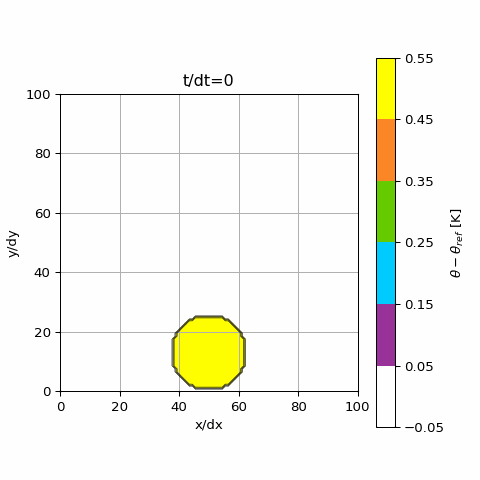

HTML(value="<a href='./boussinesq_2d_anim.gif' target='_blank'>./boussinesq_2d_anim.gif</a><br>")

In [16]:
#| echo: true
#| output-location: slide
freq = int(10)
progress = ipywidgets.FloatProgress(max=len(output)/freq)

def plot(step,plotflag=False):
    data = output[step]-SETUP.Tht_ref
    grid = data.shape
    x, y = np.indices(grid)
    colorticks = np.linspace(299.95-SETUP.Tht_ref, 300.55-SETUP.Tht_ref, 7, endpoint=True)
    cmap = colors.ListedColormap(["white", "#993399", "#00CCFF", "#66CC00","#FC8727","#FFFF00"])

    fig = pyplot.figure(figsize=(5,5))
    pyplot.title("t/dt="+str(step))
    pyplot.xlabel("x/dx")
    pyplot.ylabel("y/dy")
    pyplot.contour(x+1/2, y+1/2, data, levels=colorticks[1:], colors='k',linewidths=0.3)
    pyplot.imshow(data.T, origin="lower", extent=(0, grid[0], 0, grid[1]),
                  cmap=cmap, vmin=colorticks[0], vmax=colorticks[-1])
    pyplot.grid()
    label = "$θ-θ_{ref}$ [K]"
    if plotflag:
        cax = pyplot.axes([0.95, 0.184, 0.05,0.621])
        pyplot.colorbar(ticks=colorticks,label = label,cax = cax)
    else:
        pyplot.colorbar(ticks=colorticks,label = label)
    progress.value += 1
    return fig

display(progress)
show_anim(plot, frame_range=range(len(output))[::freq],gif_file='boussinesq_2d_anim.gif')

## Visualization using PyVista

Interactive scene, no movement

In [17]:
#| echo: true
#| output-location: slide
# pv.set_jupyter_backend('trame')
values = output[100]-SETUP.Tht_ref
values = values.reshape((*values.shape,1))
grid = pv.ImageData()
grid.dimensions = np.array(values.shape) + 1

grid.spacing = (1,1,1)
grid.cell_data['values'] = values.flatten(order='F')
grid.plot(show_edges=True)
grid.export_html("mpdata.html")

Widget(value='<iframe src="http://localhost:39029/index.html?ui=P_0x7f19755ff020_1&reconnect=auto" class="pyvi…

<iframe src="mpdata.html" width="100%" heighth="1000px" frameborder="0"></iframe>

##

Animation


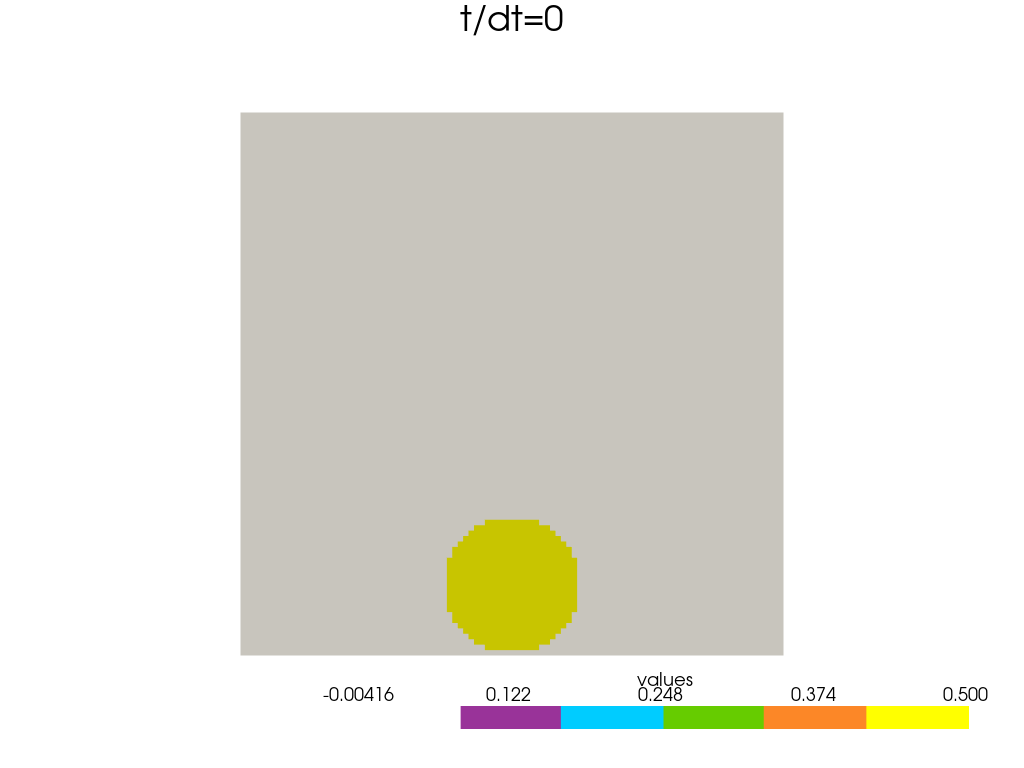

HTML(value="<a href='./tmpz_p_o6bh.gif' target='_blank'>./tmpz_p_o6bh.gif</a><br>")

In [18]:
#| echo: true
#| output-location: slide

data = np.array(output) - SETUP.Tht_ref  # shape: (401, 100, 100)
vmin, vmax = data.min(), data.max()

grid = pv.ImageData()
grid.dimensions = (*data.shape[1:], 1)  # (101, 101, 2) — wait, needs +1
grid.dimensions = (data.shape[1]+1, data.shape[2]+1, 2)
grid.cell_data['values'] = data[0].flatten(order='F')

pl = pv.Plotter(notebook=False, off_screen=True)

pl.add_mesh(
    grid,
    scalars='values',
    show_edges=False,
    cmap=colors.ListedColormap(["white", "#993399", "#00CCFF", "#66CC00","#FC8727","#FFFF00"]),
    clim=[vmin, vmax],
)

pl.view_xy()
pl.camera.parallel_projection = True

from open_atmos_jupyter_utils import TemporaryFile
gif_file = TemporaryFile(suffix=".gif")

pl.open_gif(gif_file.basename, subrectangles=True)
title_actor = None

for step in range(0, len(output), 10):
    values = output[step] - SETUP.Tht_ref
    grid.cell_data['values'] = values.flatten(order='F')

    if title_actor is not None:
        pl.remove_actor(title_actor)

    title_actor = pl.add_text(
        "t/dt=" + str(step),
        position='upper_edge',
        font_size=14,
        color='black'
    )
    pl.render()
    pl.write_frame()

pl.close()

from open_atmos_jupyter_utils import show_gif
show_gif(gif_file)

## Plans for the future {auto-animate=true auto-animate-easing="ease-in-out"}

::: {.r-hstack}

::: {data-id="box1" auto-animate-delay="0" style="background: #ffffff; width: 400px; height: 500px; margin: 10px; display: flex; align-items: center; justify-content: center; text-align: center; color: white; font-weight: bold; margin: 10px;"}
PySDM
:::

::: {data-id="box2" auto-animate-delay="0.1" style="background: #ffffff; width: 400px; height: 500px; margin: 10px; display: flex; align-items: center; justify-content: center; text-align: center; color: white; font-weight: bold; margin: 10px;"}
PyMPDATA
:::

:::

## Plans for the future {auto-animate=true auto-animate-easing="ease-in-out"}

::: {.r-stack}

::: {data-id="box1" style="background: #ffffff; width: 1000px; height: 500px; text-align: left; color: white; font-weight: bold;  border-radius: 500px;"}
PySDM
:::

::: {data-id="box1" style="background: #ffffff; width: 1000px; height: 500px; text-align: left; color: white; font-weight: bold;  border-radius: 500px;"}
PyMPDATA
:::

:::

## Bibliography

## Thank you for your attention

In [ ]:
LINK1 = "https://zfs.agh.edu.pl/"

qr = qrcode.QRCode(
    version=None,
    error_correction=ERROR_CORRECT_L,
    box_size=10,
    border=0
)
qr.add_data(LINK1)
qr.make(fit=True)

qr_img = qr.make_image(
    image_factory=SvgPathImage,
    fill_color="black",
    back_color="white",
)

qr_img.save('zfs-code.svg')

:::: {.columns}

::: {.column width="30%"}
![](team-code.svg)

Our team web page
:::

::: {.column width="30%"}
![](zfs-code.svg)

AGH Environmental Physics Group
:::

::: {.column width="30%"}
Slides created using Quarto

Background created using Canva
:::

::::